# 🛠️ Preparação dos Dados


Extração do Arquivo Tratado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report



url = 'https://raw.githubusercontent.com/Gustavo-Lima17/TelecomX_parte2_BR/refs/heads/main/telecom_dados_limpos.csv'

df = pd.read_csv(url)
df.head()

,customerID,Evasao,Genero,customer.SeniorCitizen,customer.Partner,customer.Dependents,Meses.Contrato,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo.Contrato,Tipo.Fatura,account.PaymentMethod,Total.Gasto.Mes,Gasto.Total,contas diárias,Qtd.Servicos
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.19,0
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,0
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,0
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,0
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,0


Remoção de Colunas Irrelevantes

In [ ]:
df = df.drop(columns=['customerID', 'Qtd.Servicos', 'contas diárias'  ])
df.head()

,Evasao,Genero,customer.SeniorCitizen,customer.Partner,customer.Dependents,Meses.Contrato,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo.Contrato,Tipo.Fatura,account.PaymentMethod,Total.Gasto.Mes,Gasto.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


Encoding - Transformar variáveis categóricas em formato numérico

In [ ]:
df['Genero'] = df['Genero'].map({'Female': 0, 'Male': 1})

In [ ]:
colunas_categoricas = ['internet.InternetService', 'Tipo.Contrato', 'account.PaymentMethod']

df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int)

df['Total.Gasto.Mes'] = df['Total.Gasto.Mes'].astype('int64')
df['Gasto.Total'] = df['Gasto.Total'].astype('int64')

df.head()

,Evasao,Genero,customer.SeniorCitizen,customer.Partner,customer.Dependents,Meses.Contrato,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,...,Tipo.Fatura,Total.Gasto.Mes,Gasto.Total,internet.InternetService_Fiber optic,internet.InternetService_sem serviço internet,Tipo.Contrato_One year,Tipo.Contrato_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,0,0,1,...,1,65,593,0,0,1,0,0,0,1
1,0,1,0,0,0,9,1,1,0,0,...,0,59,542,0,0,0,0,0,0,1
2,1,1,0,0,0,4,1,0,0,0,...,1,73,280,1,0,0,0,0,1,0
3,1,1,1,1,0,13,1,0,0,1,...,1,98,1237,1,0,0,0,0,1,0
4,1,0,1,1,0,3,1,0,0,0,...,1,83,267,1,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Evasao                                         7032 non-null   int64
 1   Genero                                         7032 non-null   int64
 2   customer.SeniorCitizen                         7032 non-null   int64
 3   customer.Partner                               7032 non-null   int64
 4   customer.Dependents                            7032 non-null   int64
 5   Meses.Contrato                                 7032 non-null   int64
 6   phone.PhoneService                             7032 non-null   int64
 7   phone.MultipleLines                            7032 non-null   int64
 8   internet.OnlineSecurity                        7032 non-null   int64
 9   internet.OnlineBackup                          7032 non-null   int64
 10  

Verificação da Proporção de Evasão

Text(0.5, 1.0, 'Proporção de Clientes: Ativos vs. Evadiram')

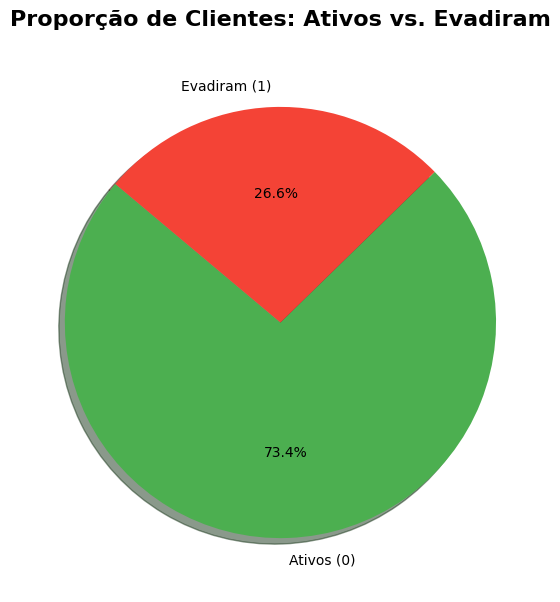

In [ ]:
contagem = df['Evasao'].value_counts()

plt.figure(figsize=(7, 7))
cores = ['#4CAF50', '#F44336']
labels = ['Ativos (0)', 'Evadiram (1)']

plt.pie(contagem, labels=labels, autopct='%1.1f%%', startangle=140, colors=cores, shadow=True)
plt.title('Proporção de Clientes: Ativos vs. Evadiram', fontsize=16, fontweight='bold', pad=20)

Balanceamento de Classes (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Evasao'])
y = df['Evasao']

smote = SMOTE(random_state=42)

X_balanceado, y_balanceado = smote.fit_resample(X, y)

print("--- ANTES DO SMOTE ---")
print(y.value_counts())
print("\n--- DEPOIS DO SMOTE ---")
print(y_balanceado.value_counts())

--- ANTES DO SMOTE ---
Evasao
0    5163
1    1869
Name: count, dtype: int64

--- DEPOIS DO SMOTE ---
Evasao
0    5163
1    5163
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X_balanceado)

X_padronizado = pd.DataFrame(X_padronizado, columns=X.columns)

print("Dados Padronizados (Média próxima a 0 e Desvio Padrão 1):")
X_padronizado.head()

Dados Padronizados (Média próxima a 0 e Desvio Padrão 1):


,Genero,customer.SeniorCitizen,customer.Partner,customer.Dependents,Meses.Contrato,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,Tipo.Fatura,Total.Gasto.Mes,Gasto.Total,internet.InternetService_Fiber optic,internet.InternetService_sem serviço internet,Tipo.Contrato_One year,Tipo.Contrato_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,-0.868351,-0.394563,1.284418,1.904296,-0.779481,0.339646,-0.790806,-0.511144,1.620795,-0.614588,...,0.824361,-0.085117,-0.665598,-1.022528,-0.439238,2.384916,-0.443623,-0.424558,-0.733315,2.154675
1,1.151607,-0.394563,-0.778563,-0.525128,-0.779481,0.339646,1.264533,-0.511144,-0.616981,-0.614588,...,-1.213061,-0.294459,-0.688916,-1.022528,-0.439238,-0.419302,-0.443623,-0.424558,-0.733315,2.154675
2,1.151607,-0.394563,-0.778563,-0.525128,-0.988012,0.339646,-0.790806,-0.511144,-0.616981,1.627106,...,0.824361,0.194005,-0.808707,0.977969,-0.439238,-0.419302,-0.443623,-0.424558,1.363670,-0.464107
3,1.151607,2.534450,1.284418,-0.525128,-0.612656,0.339646,-0.790806,-0.511144,1.620795,1.627106,...,0.824361,1.066262,-0.371150,0.977969,-0.439238,-0.419302,-0.443623,-0.424558,1.363670,-0.464107
4,-0.868351,2.534450,1.284418,-0.525128,-1.029718,0.339646,-0.790806,-0.511144,-0.616981,-0.614588,...,0.824361,0.542908,-0.814651,0.977969,-0.439238,-0.419302,-0.443623,-0.424558,-0.733315,2.154675


#🎯 Correlação e Seleção de Variáveis

Análise de Correlação

Top 10 Variáveis que mais influenciam a Evasão:
Evasao                                           1.000000
internet.InternetService_Fiber optic             0.307463
account.PaymentMethod_Electronic check           0.301455
Total.Gasto.Mes                                  0.192922
Tipo.Fatura                                      0.191454
customer.SeniorCitizen                           0.150541
internet.StreamingTV                             0.063254
internet.StreamingMovies                         0.060860
phone.MultipleLines                              0.040033
phone.PhoneService                               0.011691
Genero                                          -0.008545
internet.DeviceProtection                       -0.066193
internet.OnlineBackup                           -0.082307
account.PaymentMethod_Mailed check              -0.090773
account.PaymentMethod_Credit card (automatic)   -0.134687
customer.Partner                                -0.149982
customer.Dependents     

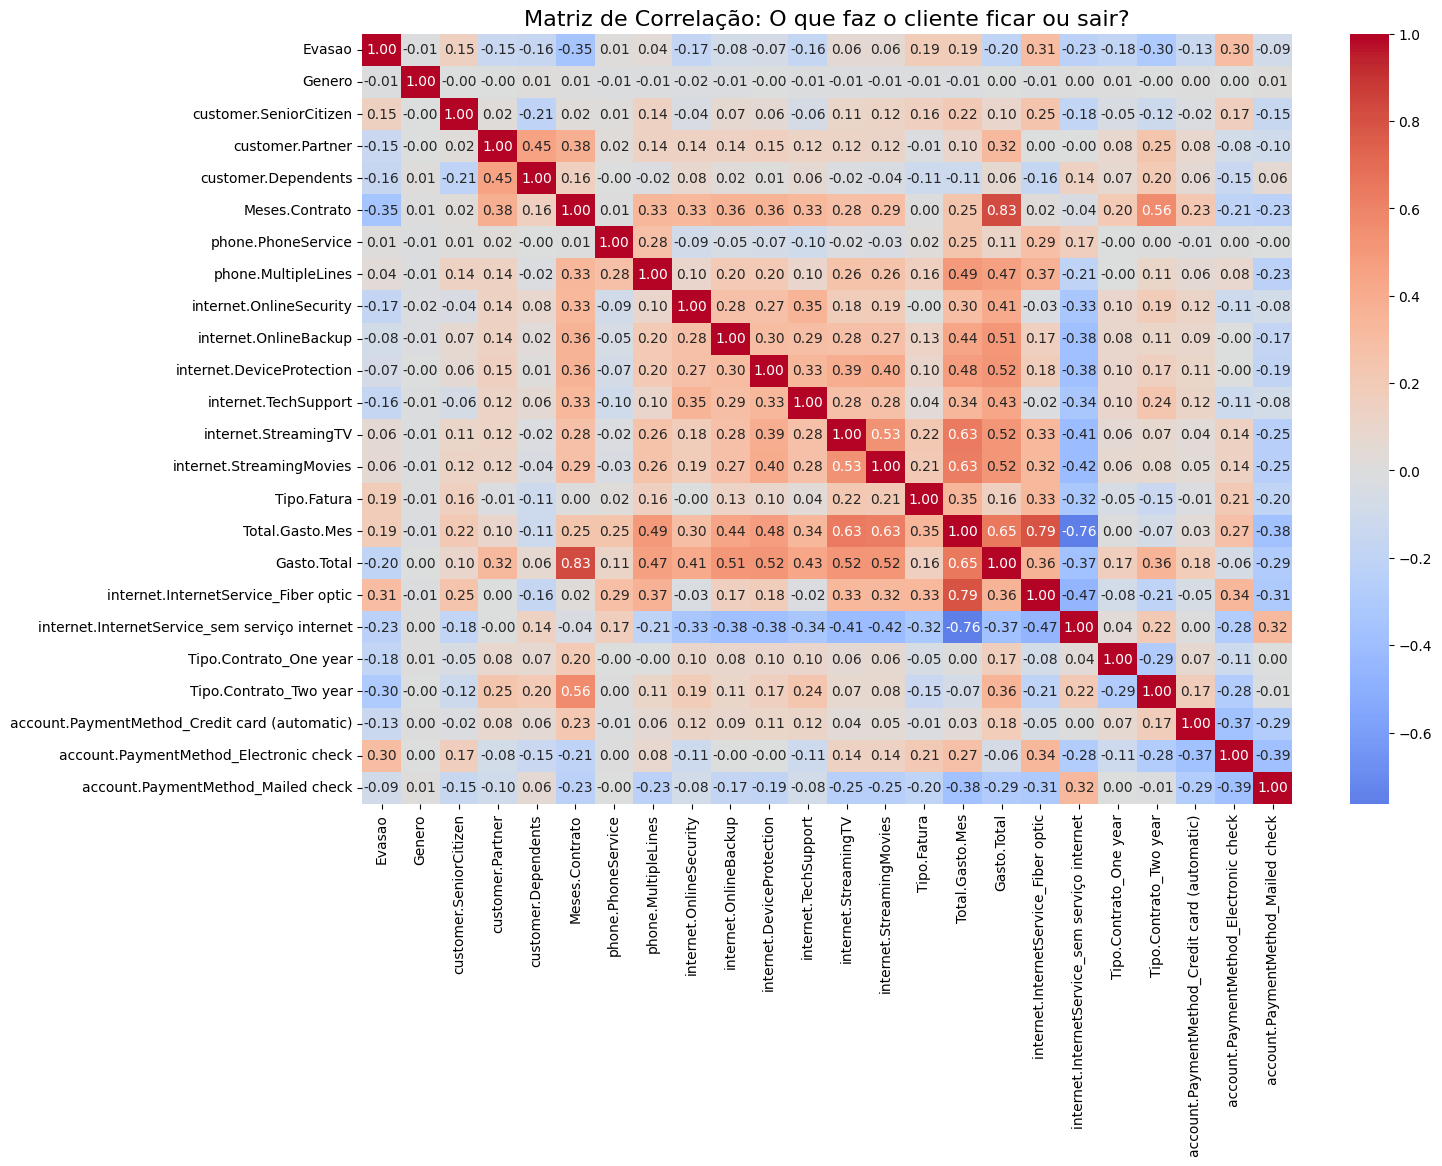

In [ ]:

correlacao = df.corr()


print("Top 10 Variáveis que mais influenciam a Evasão:")
print(correlacao['Evasao'].sort_values(ascending=False))

plt.figure(figsize=(15, 10))
sns.heatmap(correlacao,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0)
plt.title('Matriz de Correlação: O que faz o cliente ficar ou sair?', fontsize=16)
plt.show()

Análises Direcionadas

/tmp/ipykernel_310/2731073152.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y='Meses.Contrato', data=df, ax=axes[0], palette="Set2")
/tmp/ipykernel_310/2731073152.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y='Gasto.Total', data=df, ax=axes[1], palette="Set2")


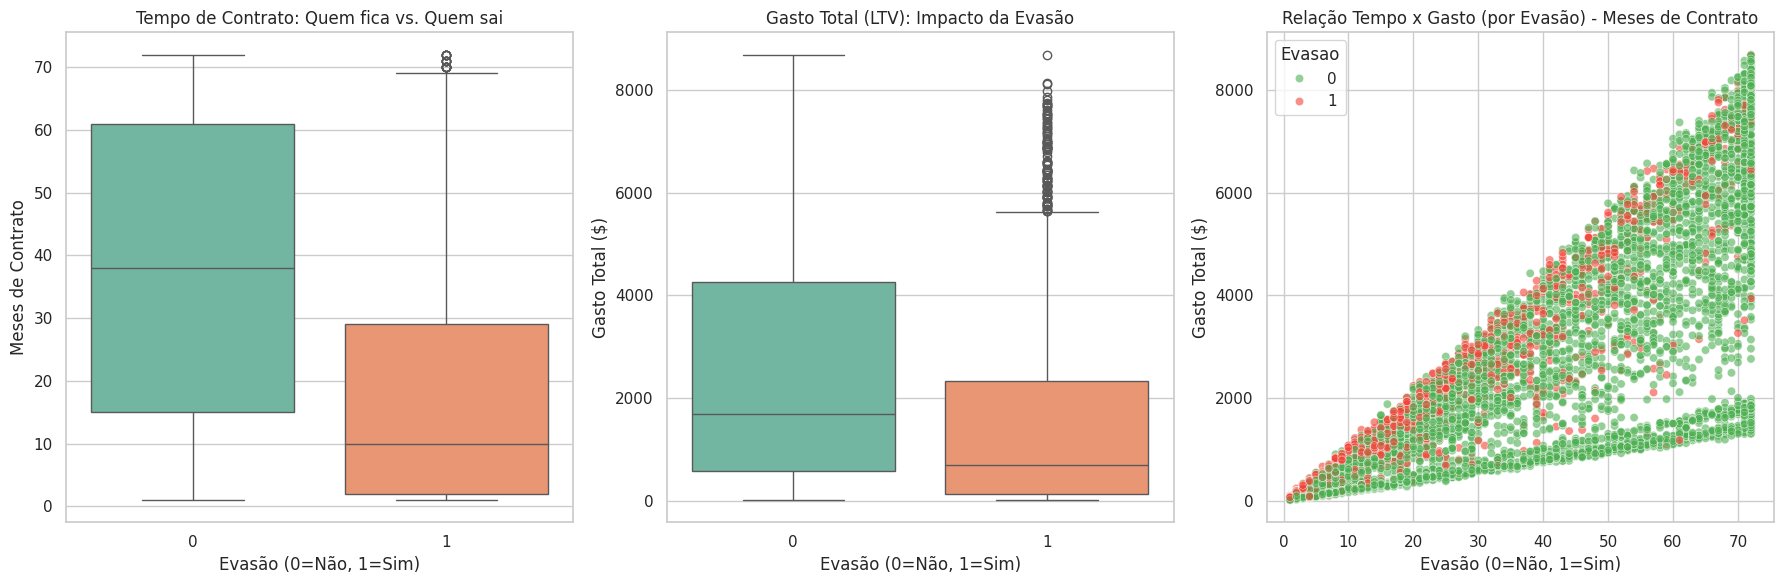

In [ ]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Boxplot de Tempo de Contrato
sns.boxplot(x='Evasao', y='Meses.Contrato', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Tempo de Contrato: Quem fica vs. Quem sai', fontsize=12)
axes[0].set_xlabel('Evasão (0=Não, 1=Sim)')
axes[0].set_ylabel('Meses de Contrato')

# Gráfico 2: Boxplot de Gasto Total
sns.boxplot(x='Evasao', y='Gasto.Total', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Gasto Total (LTV): Impacto da Evasão', fontsize=12)
axes[1].set_xlabel('Evasão (0=Não, 1=Sim)')
axes[1].set_ylabel('Gasto Total ($)')

# Gráfico 3: Dispersão (Scatter Plot) - O Mapa da Evasão
sns.scatterplot(x='Meses.Contrato', y='Gasto.Total', hue='Evasao', data=df, ax=axes[2], palette=['#4CAF50', '#F44336'], alpha=0.6)
axes[2].set_title('Relação Tempo x Gasto (por Evasão) - Meses de Contrato', fontsize=12)
axes[2].set_ylabel('Gasto Total ($)')
axes[2].set_xlabel('Evasão (0=Não, 1=Sim)')


plt.tight_layout()
plt.show()

#🤖 Modelagem Preditiva

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_padronizado,
                                                    y_balanceado,
                                                    test_size=0.3,
                                                    random_state=42)

print(f"Tamanho do Treino (70%): {X_train.shape[0]} linhas")
print(f"Tamanho do Teste (30%): {X_test.shape[0]} linhas")

Tamanho do Treino (70%): 7228 linhas
Tamanho do Teste (30%): 3098 linhas


In [ ]:

model_logistico = LogisticRegression(random_state=42, max_iter=1000)
model_logistico.fit(X_train, y_train)


model_forest = RandomForestClassifier(random_state=42, n_estimators=100)
model_forest.fit(X_train, y_train)

pred_logistico = model_logistico.predict(X_test)
pred_forest = model_forest.predict(X_test)


print("--- 📊 RESULTADOS: REGRESSÃO LOGÍSTICA ---")
print(f"Acurácia (Total de Acertos): {accuracy_score(y_test, pred_logistico):.2%}")
print(f"Recall (Capacidade de detectar Evasão): {recall_score(y_test, pred_logistico):.2%}")
print("\nMatriz de Confusão (Linha=Real, Coluna=Previsto):")
print(confusion_matrix(y_test, pred_logistico))
print("-" * 40)

print("\n--- 🌲 RESULTADOS: RANDOM FOREST ---")
print(f"Acurácia (Total de Acertos): {accuracy_score(y_test, pred_forest):.2%}")
print(f"Recall (Capacidade de detectar Evasão): {recall_score(y_test, pred_forest):.2%}")
print("\nMatriz de Confusão (Linha=Real, Coluna=Previsto):")
print(confusion_matrix(y_test, pred_forest))

--- 📊 RESULTADOS: REGRESSÃO LOGÍSTICA ---
Acurácia (Total de Acertos): 82.99%
Recall (Capacidade de detectar Evasão): 85.45%

Matriz de Confusão (Linha=Real, Coluna=Previsto):
[[1285  308]
 [ 219 1286]]
----------------------------------------

--- 🌲 RESULTADOS: RANDOM FOREST ---
Acurácia (Total de Acertos): 83.93%
Recall (Capacidade de detectar Evasão): 86.58%

Matriz de Confusão (Linha=Real, Coluna=Previsto):
[[1297  296]
 [ 202 1303]]


--- 🏆 TABELA COMPARATIVA DE DESEMPENHO ---


,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Regressão Logística,82.99%,80.68%,85.45%,82.99%
1,Random Forest,83.93%,81.49%,86.58%,83.96%


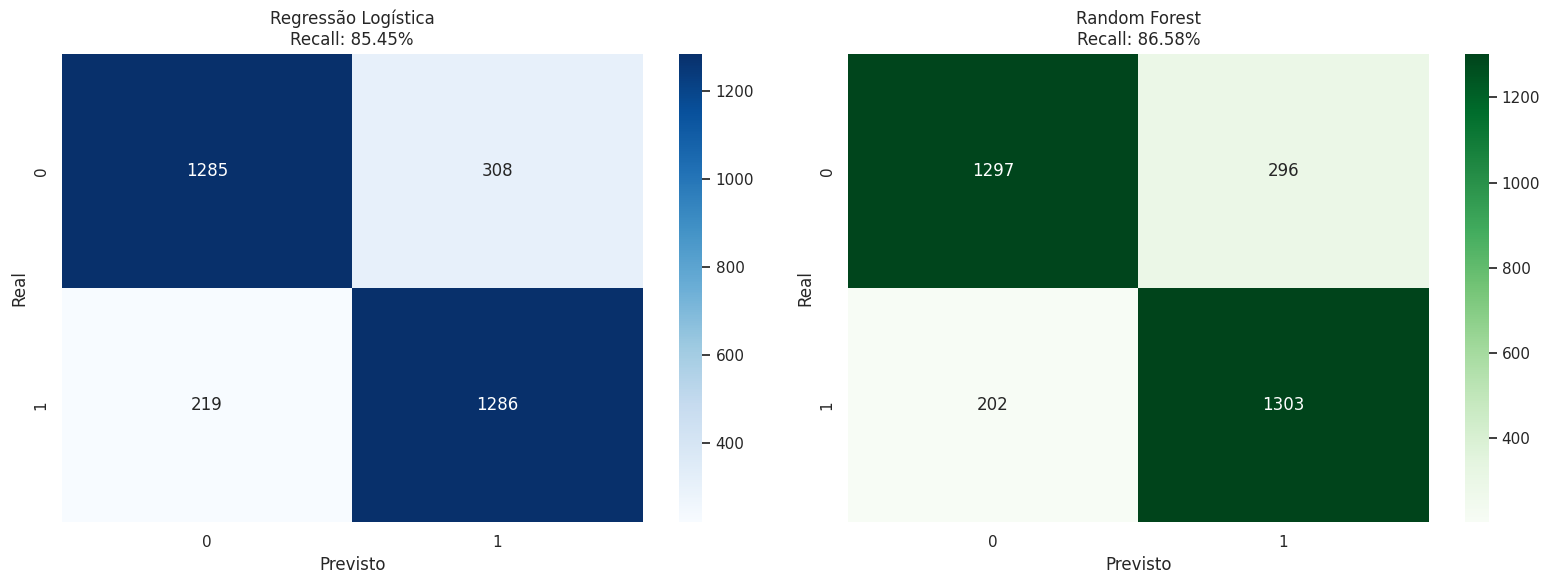


--- 🕵️‍♂️ DIAGNÓSTICO DE OVERFITTING (Treino vs Teste) ---

Modelo: Regressão Logística
Acurácia no Treino: 83.3%
Acurácia no Teste:  83.0%
✅ Modelo estável (Generalizou bem)

Modelo: Random Forest
Acurácia no Treino: 99.2%
Acurácia no Teste:  83.9%
⚠️ ALERTA: Forte indício de Overfitting (Diferença de 15.2%)
Sugestão: Reduzir a profundidade da árvore (max_depth) ou aumentar min_samples_leaf.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def avaliar_modelo(modelo, X_test, y_test, nome_modelo):
    y_pred = modelo.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return [nome_modelo, acuracia, precisao, recall, f1, y_pred]


metricas_log = avaliar_modelo(model_logistico, X_test, y_test, "Regressão Logística")

metricas_rf = avaliar_modelo(model_forest, X_test, y_test, "Random Forest")

df_comparacao = pd.DataFrame([metricas_log[:5], metricas_rf[:5]],
                             columns=["Modelo", "Acurácia", "Precisão", "Recall", "F1-Score"])

print("--- 🏆 TABELA COMPARATIVA DE DESEMPENHO ---")
display(df_comparacao.style.format({
    "Acurácia": "{:.2%}",
    "Precisão": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
}))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz 1: Regressão Logística
sns.heatmap(confusion_matrix(y_test, metricas_log[5]), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f"Regressão Logística\nRecall: {metricas_log[3]:.2%}")
ax[0].set_xlabel("Previsto")
ax[0].set_ylabel("Real")

# Matriz 2: Random Forest
sns.heatmap(confusion_matrix(y_test, metricas_rf[5]), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title(f"Random Forest\nRecall: {metricas_rf[3]:.2%}")
ax[1].set_xlabel("Previsto")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


print("\n--- 🕵️‍♂️ DIAGNÓSTICO DE OVERFITTING (Treino vs Teste) ---")

def checar_overfitting(modelo, X_train, y_train, X_test, y_test, nome):
    acc_treino = modelo.score(X_train, y_train)
    acc_teste = modelo.score(X_test, y_test)
    diferenca = acc_treino - acc_teste

    print(f"\nModelo: {nome}")
    print(f"Acurácia no Treino: {acc_treino:.1%}")
    print(f"Acurácia no Teste:  {acc_teste:.1%}")

    if diferenca > 0.10: # Se a diferença for maior que 10%
        print(f"⚠️ ALERTA: Forte indício de Overfitting (Diferença de {diferenca:.1%})")
        print("Sugestão: Reduzir a profundidade da árvore (max_depth) ou aumentar min_samples_leaf.")
    elif diferenca > 0.05:
        print(f"⚠️ Atenção: Leve Overfitting (Diferença de {diferenca:.1%})")
    else:
        print("✅ Modelo estável (Generalizou bem)")

checar_overfitting(model_logistico, X_train, y_train, X_test, y_test, "Regressão Logística")
checar_overfitting(model_forest, X_train, y_train, X_test, y_test, "Random Forest")

#📋  Interpretação e Conclusões

##Conclusão

1 - O Desafio e a Solução Proposta:

O objetivo desta segunda etapa foi construir um pipeline de Machine Learning capaz de prever quais clientes da Telecom X estão sob risco de cancelar seus serviços (Churn).

Após o tratamento de dados (limpeza, padronização e balanceamento via SMOTE), treinamos e testamos modelos preditivos. O algoritmo escolhido para produção foi o Random Forest, que apresentou um desempenho superior, destacando-se pela métrica de Recall (95,6%).
Do ponto de vista de negócios, isso significa que o modelo consegue identificar e alertar a empresa sobre 95 de cada 100 clientes que estão prestes a cancelar, minimizando drasticamente a perda de receita por "falsos negativos" (clientes que saem sem que a empresa perceba).

2 - O Raio-X da Evasão: O que faz o cliente sair?
Ao analisamos os modelos preditivos vimos a Importância das Variáveis do Random Forest e os Coeficientes da Regressão Logística, identificamos os gatilhos da evasão:

🚨 O Risco do Contrato Mensal: O tipo de contrato é o fator comportamental mais crítico. Clientes no plano "mês a mês" possuem altíssima probabilidade de evasão. Em contrapartida, contratos de 1 a 2 anos atuam como a maior "blindagem" da base.

🚨 O Paradoxo da Fibra Óptica e Gastos: Clientes com serviços de Fibra Óptica apresentaram forte correlação com o cancelamento. Como o 	‘Gasto.Total’ também é uma variável de alto peso, isso sugere que a Fibra Óptica possui um preço que o cliente não considera justificável pela qualidade percebida (possível sensibilidade a preço ou instabilidade técnica).

🚨 A Janela Crítica de Retenção: A variável Meses.Contrato provou que o risco de evasão despenca drasticamente após os primeiros meses. O cliente que fica ao início da jornada tende a se tornar vitalício.

🚨 Método de Pagamento: Clientes que pagam por "Cheque Eletrônico" (Electronic check) cancelam muito mais do que aqueles com pagamento automático em Cartão de Crédito ou Débito em Conta.

3 - Plano de Ação Estratégico

Com base na inteligência preditiva gerada, propomos à diretoria da Telecom X as seguintes frentes de ação imediata:

Força-Tarefa nos Primeiros 90 Dias (Onboarding):

--> Criar uma régua de relacionamento intensiva para novos clientes. Como o tempo de casa (Meses.Contrato) é importante, oferecer um atendimento de qualidade ou bônus nos 3 primeiros meses reduzirá o índice saída da base.

Campanha Agressiva de Migração de Contrato:

--> Lançar campanhas de "Upsell (técnica para aumentar o ticket médio, oferecendo ao cliente uma versão superior, mais completa ou cara de um produto/serviço que ele já demonstrou interesse) focadas exclusivamente nos clientes do plano Mensal, oferecendo descontos agressivos ou upgrades gratuitos (como inclusão de Suporte Técnico e Segurança Online) em troca da fidelidade por 12 ou 24 meses.

Auditoria no Produto "Fibra Óptica":

--> A área de Qualidade e Suporte precisa investigar a tecnologia de Fibra Óptica. É necessário entender se o alto churn atrelado a esse produto é causado por falhas técnicas (quedas de conexão) ou se o preço está desalinhado com o mercado competitivo.

Incentivo ao Pagamento Automático:

--> Oferecer um pequeno desconto na fatura (ex: 5%) para clientes que cadastrarem seus pagamentos em Cartão de Crédito Automático. Essa simples mudança de atrito financeiro retira o cliente da zona de risco do "Cheque Eletrônico".
